# F — Séries temporelles & prévision (EventZilla)

**Objectif** : série mensuelle DW (ex. volume, CA, panier) ; **stationnarité** (ADF / KPSS si présents) ; **décomposition** ; **≥ 2 modèles** (ex. **Holt** vs **ARIMA**) ; métriques **RMSE, MAE, MAPE** sur validation.

Contrairement au ML tabulaire, le **temps** impose l’ordre des observations : on ne mélange pas aléatoirement train et test sous peine de **fuite d’information** (le modèle « voit » le futur). L’objectif métier est souvent un **horizon court** (quelques mois) pour anticiper charge ou volumes.

**Grille F** : analyse stationnarité + décomposition ; comparaison modèles ; erreurs de prévision ; lecture des graphes **réel vs ajusté** et **horizon**.

**B** : ARIMA — structure AR/I/MA ; Holt — tendance + lissage exponentiel ; limites si saisonnalité forte non modélisée (selon spec). Détail : **`06_B_comprehension_modeles.ipynb`**.

Références : dashboards EventZilla.


## Référence F

Stationnarité (ADF, KPSS) ; décomposition ; **≥ 2** modèles de prévision ; **MAPE, RMSE, MAE** ; analyse des erreurs sur horizon.

**Ordre d'exécution** : cellule connexion → imports → chargement série → analyses → modèles → sauvegarde.

**ADF vs KPSS** : en pratique on les croise — des conclusions contradictoires signalent souvent une série **proche** de la non-stationnarité ou une fenêtre trop courte ; la décomposition visuelle et la différenciation (`d` en ARIMA) aident à trancher pour le rapport.


In [1]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

# Connexion DW — diagnostic (même serveur / base que SSMS)
from ML.ml_paths import (
    DATABASE_DW,
    SQL_SERVER,
    SQL_DRIVER,
    SQL_PORT,
    build_windows_auth_uri,
    get_sql_engine,
    ml_sql_only,
    read_dw_sql,
    sql_engine_init_error,
)

print("=" * 62)
print(" EVENTZILLA — Connexion DW (équivalent accès SSMS)")
print("=" * 62)
print("  Serveur SQL      :", SQL_SERVER + (":" + str(SQL_PORT) if SQL_PORT else ""))
print("  Base DW cible    :", DATABASE_DW)
print("  Driver ODBC      :", SQL_DRIVER)
print("  Mode DW seul     :", ml_sql_only(), "(EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)")
try:
    _uri = build_windows_auth_uri()
    print("  Chaîne (extrait) :", (_uri[:88] + "…") if len(_uri) > 88 else _uri)
except Exception as _uerr:
    print("  Chaîne URI       : erreur", _uerr)
_eng = get_sql_engine()
if _eng is not None:
    try:
        _chk = read_dw_sql(
            "SELECT DB_NAME() AS base_active, CAST(SERVERPROPERTY('ServerName') AS NVARCHAR(128)) AS serveur",
            _eng,
        )
        print("  Test SQL         : OK — même base que sous SSMS si base_active =", DATABASE_DW)
        print(_chk.to_string(index=False))
    except Exception as _qerr:
        print("  Test SQL         : ÉCHEC —", _qerr)
else:
    print("  Engine           : ABSENT —", sql_engine_init_error() or "voir pip sqlalchemy pyodbc")
print("=" * 62)


 EVENTZILLA — Connexion DW (équivalent accès SSMS)
  Serveur SQL      : ASUSRANIM
  Base DW cible    : DW_eventzella
  Driver ODBC      : ODBC Driver 17 for SQL Server
  Mode DW seul     : True (EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)
  Chaîne (extrait) : mssql+pyodbc://@ASUSRANIM/DW_eventzella?driver=ODBC+Driver+17+for+SQL+Server&trusted_con…
  Test SQL         : OK — même base que sous SSMS si base_active = DW_eventzella
  base_active   serveur
DW_eventzella AsusRanim


In [2]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

%matplotlib inline
import json
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

from ML.csv_local_fallback import load_reservation_dataframe, monthly_series_from_reservation
from ML.ml_paths import ML_PROCESSED, ML_MODELS, ensure_processed_dirs, get_sql_engine, ml_sql_only, read_dw_sql
from ML.schema_eventzilla import SQL_ML_TIME_SERIES_RESERVATIONS

ensure_processed_dirs()
ML_MODELS.mkdir(parents=True, exist_ok=True)
print("[1] Séries temporelles critère F. ML_SQL_ONLY:", ml_sql_only())


[1] Séries temporelles critère F. ML_SQL_ONLY: True


In [3]:
df_ts = None
eng = get_sql_engine()
if eng is not None:
    try:
        df_ts = read_dw_sql(SQL_ML_TIME_SERIES_RESERVATIONS, eng)
        print("[2] Source : agrégat SQL mensuel (SSMS).")
    except Exception as e:
        if ml_sql_only():
            raise RuntimeError("[2] Lecture SQL obligatoire : " + str(e)) from e
        print("[2] SQL indisponible, local :", e)
if df_ts is None:
    if ml_sql_only():
        raise RuntimeError("[2] Aucune donnée (EVENTZILLA_ML_SQL_ONLY=1).")
    df_ts = monthly_series_from_reservation(load_reservation_dataframe())
    print("[2] Source : Reservation (ML_SQL_ONLY=0).")
df_ts["date"] = pd.to_datetime(
    dict(year=df_ts["cal_year"].astype(int), month=df_ts["cal_month"].astype(int), day=1)
)
print(df_ts.head())


[2] Source : agrégat SQL mensuel (SSMS).
   cal_year  cal_month  nb_fact_rows  revenue_sum  avg_final_price       date
0      2022          1           548    5264366.0      9606.507299 2022-01-01
1      2022          2           476    5508520.0     11572.521008 2022-02-01
2      2022          3           598    5993532.0     10022.628763 2022-03-01
3      2022          4           580    5133904.0      8851.558621 2022-04-01
4      2022          5           526    5391808.0     10250.585551 2022-05-01


### Figures Matplotlib

Les graphiques s'affichent sous la cellule avec `plt.show()` (mode inline).


### Après imports

Prêt pour chargement série et analyses F.



[3] --- Cible Y_t retenue ---
[3]   colonne SQL      : nb_fact_rows
[3]   signification    : Volume mensuel d'activité (nombre de lignes de faits comptées dans le DW par mois).
[3]   id KPI (export)  : count_id_reservation_mensuel_anticipation
[3] ADF — stat: -4.4423 | p-value: 0.0002 | (p<0.05 : rejet H0 racine unitaire, serie plutot stationnaire)
[3] KPSS — stat: 0.1165 | p-value: 0.1 | (croiser avec ADF et graphiques)


C:\Users\ranim\AppData\Local\Temp\ipykernel_30228\4149175603.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(ts.dropna(), regression="c", nlags="auto")


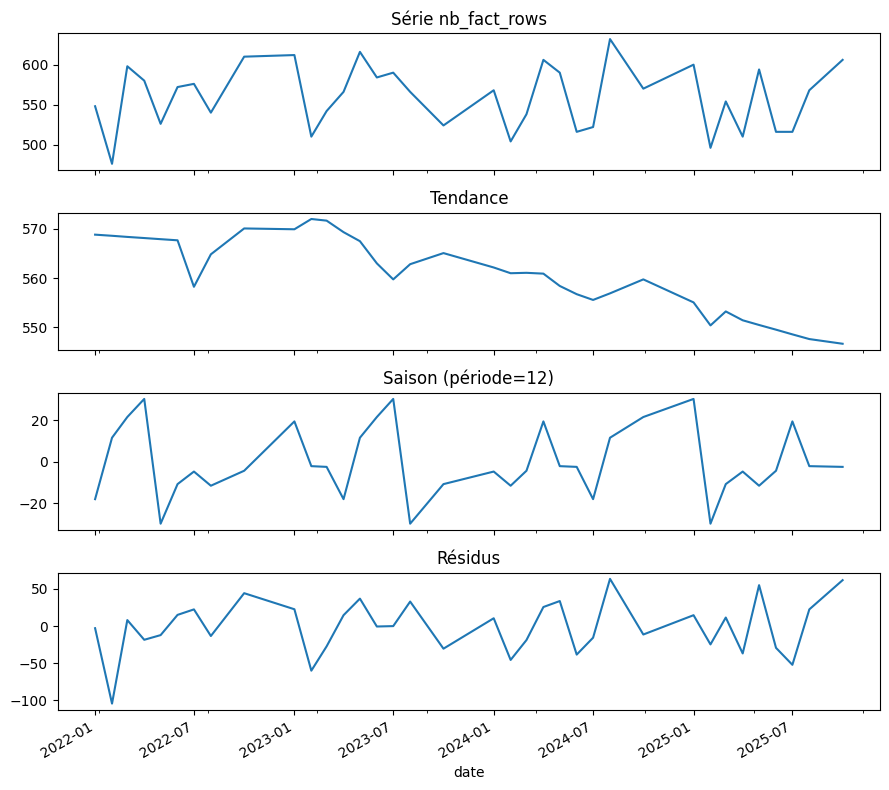

In [4]:
SERIES_KPIS = [
    ("nb_fact_rows", "count_id_reservation_mensuel_anticipation"),
    ("revenue_sum", "ca_mensuel_sum_final_price_projection"),
    ("avg_final_price", "panier_moyen_mensuel_projection"),
]
TARGET_DEF = {
    "nb_fact_rows": "Volume mensuel d'activité (nombre de lignes de faits comptées dans le DW par mois).",
    "revenue_sum": "Chiffre d'affaires mensuel (somme des montants final_price).",
    "avg_final_price": "Panier moyen mensuel (moyenne des final_price).",
}

col_main = next((c for c, _ in SERIES_KPIS if c in df_ts.columns), None)
if col_main is None:
    raise ValueError("[3] Aucune colonne séries reconnue.")

print("[3] --- Cible Y_t retenue ---")
print("[3]   colonne SQL      :", col_main)
print("[3]   signification    :", TARGET_DEF[col_main])
print("[3]   id KPI (export)  :", dict(SERIES_KPIS)[col_main])

ts = df_ts.set_index("date")[col_main].astype(float).sort_index()
if len(ts) < 8:
    raise ValueError("[3] Historique trop court pour ADF/KPSS/prévision fiable.")

adf_res = adfuller(ts.dropna(), autolag="AIC")
adf_stat, adf_p = float(adf_res[0]), float(adf_res[1])
print("[3] ADF — stat:", round(adf_stat, 4), "| p-value:", round(adf_p, 4), "| (p<0.05 : rejet H0 racine unitaire, serie plutot stationnaire)")

try:
    kpss_res = kpss(ts.dropna(), regression="c", nlags="auto")
    kpss_stat, kpss_p = float(kpss_res[0]), float(kpss_res[1])
    print("[3] KPSS — stat:", round(kpss_stat, 4), "| p-value:", round(kpss_p, 4), "| (croiser avec ADF et graphiques)")
except Exception as _e:
    kpss_stat, kpss_p = None, None
    print("[3] KPSS indisponible :", _e)

period = min(12, max(2, len(ts) // 3))
try:
    decomp = seasonal_decompose(ts, model="additive", period=period, extrapolate_trend="freq")
    fig, ax = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
    decomp.observed.plot(ax=ax[0], title="Série " + col_main)
    decomp.trend.plot(ax=ax[1], title="Tendance")
    decomp.seasonal.plot(ax=ax[2], title="Saison (période=" + str(period) + ")")
    decomp.resid.plot(ax=ax[3], title="Résidus")
    plt.tight_layout()
    plt.show()
except Exception as ex:
    print("[3] Décomposition ignorée :", ex)

## 3. Série & exploratoire

**Interprétation (après plots)** :

| Élément | Lecture |
|---------|---------|
| **Série brute** | Tendance, saisonnalité, ruptures |
| **ADF / KPSS** | p-value ADF faible → rejet racine unitaire (souvent stationnaire en diff) ; KPSS en complément |
| **Décomposition** | Part tendance / saison / résidu — guide le choix Holt vs ARIMA(p,d,q) |
| **ACF/PACF** (si présent) | Ordres AR/MA indicatifs |

Si la **composante saisonnière** domine visuellement alors que Holt est sans saisonnalité dans ce notebook, mentionnez explicitement cette **limite** dans le rapport (piste : Holt-Winters ou SARIMA en extension).


### Après chargement série

Fréquence mensuelle cohérente ; pas trop de trous (sinon imputation documentée dans le code).

Vérifiez aussi que l’agrégation mensuelle correspond bien au **KPI** attendu (somme de lignes, CA moyen, etc.) : une série mal définie rend les métriques MAPE/RMSE difficiles à défendre face au métier.


## 4. Train / test temporel

Coupe **chronologique** (pas de fuite future). **Validation** sur la fin d’historique.

La taille du **holdout** (souvent quelques mois) fixe la précision avec laquelle vous estimez l’erreur : trop court = variance élevée des métriques ; trop long = moins de données pour ajuster la tendance. Justifiez ce compromis dans le rapport si le correcteur le demande.


In [5]:
def metrics_ts(y_true, y_pred):
    e = y_true - y_pred
    rmse = float(np.sqrt(np.mean(e ** 2)))
    mae = float(np.mean(np.abs(e)))
    mape = float(np.mean(np.abs(e / (y_true + 1e-9))) * 100)
    return {"rmse": rmse, "mae": mae, "mape": mape}


HORIZON_HOLDOUT_MONTHS = 3
train = ts.iloc[:-HORIZON_HOLDOUT_MONTHS]
test = ts.iloc[-HORIZON_HOLDOUT_MONTHS:]
h = len(test)
print("[4] Découpage — train :", len(train), "mois | test (holdout) :", h, "mois | Y_t :", col_main)

fit_holt = ExponentialSmoothing(
    train, trend="add", seasonal=None, initialization_method="estimated"
).fit()
fc_holt = fit_holt.forecast(h)
m_holt = metrics_ts(test.values, fc_holt.values)
print("[4] Holt — métriques test :", {k: round(v, 6) for k, v in m_holt.items()})

[4] Découpage — train : 33 mois | test (holdout) : 3 mois | Y_t : nb_fact_rows
[4] Holt — métriques test : {'rmse': 38.047319, 'mae': 34.549319, 'mape': 6.124521}


c:\Users\ranim\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ranim\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 5. Modèles & comparaison

**Holt vs ARIMA** (ou équivalent dans le code) : comparer **RMSE/MAE/MAPE** sur la même fenêtre test.

**Interprétation des courbes** :

| Courbe | Lecture |
|--------|---------|
| **Réel vs prédit (test)** | Écart systématique = biais ; pics manqués = sous-modélisation saison/tendance |
| **Prévision horizon** | Élargissement incertitude normal ; comparer les deux modèles sur le **même** horizon |
| **Résidus série** | Doit ressembler à du bruit si le modèle capture la structure |

Un **champion** au RMSE très serré entre Holt et ARIMA est fréquent sur des séries lisses : dans ce cas, la **simplicité** et la **stabilité** Holt peuvent primer pour la mise en production, ou ARIMA si vous valorisez une structure ARMA explicite (critère **B**).


[4] ARIMA — métriques test : {'rmse': 38.650287, 'mae': 34.293166, 'mape': 6.144083}
[4] --- Comparaison (mêmes mois de test pour les deux modèles) ---
[4] Holt   RMSE: 38.047319  MAE: 34.549319  MAPE %: 6.1245
[4] ARIMA  RMSE: 38.650287  MAE: 34.293166  MAPE %: 6.1441
[4] >>> CHAMPION : Holt (RMSE le plus bas). Delta RMSE (Holt - ARIMA) = -0.602968


c:\Users\ranim\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ranim\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ranim\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ranim\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

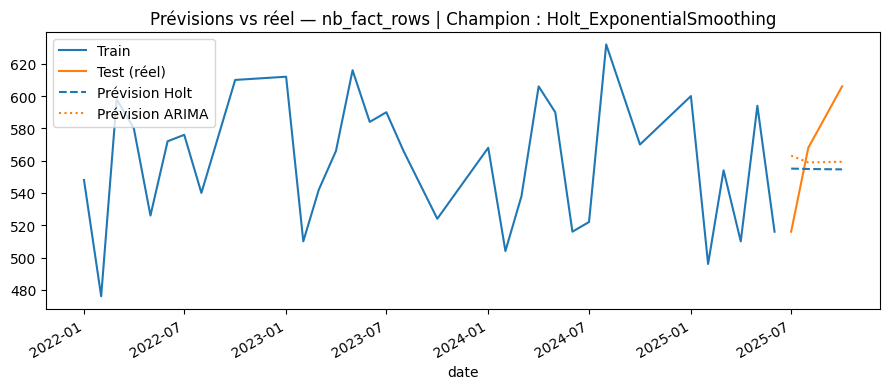

In [6]:
try:
    arima_fit = ARIMA(train, order=(1, 1, 1)).fit()
except Exception:
    arima_fit = ARIMA(train, order=(0, 1, 1)).fit()
fc_arima = arima_fit.forecast(h)
m_arima = metrics_ts(test.values, np.asarray(fc_arima, dtype=float).ravel())

print("[4] ARIMA — métriques test :", {k: round(v, 6) for k, v in m_arima.items()})
print("[4] --- Comparaison (mêmes mois de test pour les deux modèles) ---")
print("[4] Holt   RMSE:", round(m_holt["rmse"], 6), " MAE:", round(m_holt["mae"], 6), " MAPE %:", round(m_holt["mape"], 4))
print("[4] ARIMA  RMSE:", round(m_arima["rmse"], 6), " MAE:", round(m_arima["mae"], 6), " MAPE %:", round(m_arima["mape"], 4))

delta_rmse = float(m_holt["rmse"] - m_arima["rmse"])
if m_holt["rmse"] <= m_arima["rmse"]:
    primary_model, m_primary = "Holt_ExponentialSmoothing", m_holt
    print("[4] >>> CHAMPION : Holt (RMSE le plus bas). Delta RMSE (Holt - ARIMA) =", round(delta_rmse, 6))
else:
    primary_model, m_primary = "ARIMA", m_arima
    print("[4] >>> CHAMPION : ARIMA (RMSE le plus bas). Delta RMSE (Holt - ARIMA) =", round(delta_rmse, 6))

fig, ax = plt.subplots(figsize=(9, 4))
train.plot(ax=ax, label="Train", color="C0")
test.plot(ax=ax, label="Test (réel)", color="C1")
pd.Series(fc_holt.values, index=test.index).plot(ax=ax, label="Prévision Holt", ls="--")
pd.Series(np.asarray(fc_arima).ravel(), index=test.index).plot(ax=ax, label="Prévision ARIMA", ls=":")
ax.legend()
ax.set_title("Prévisions vs réel — " + str(col_main) + " | Champion : " + str(primary_model))
plt.tight_layout()
plt.show()

## 6. Sauvegarde & métriques

`metrics_timeseries.json` pour **05** et Streamlit (champion, RMSE, règle de choix).

Le JSON doit refléter **la même** fenêtre de test et la même colonne `Y_t` que celles commentées dans les sections précédentes — sinon la synthèse **05** ne sera pas alignée avec vos graphiques.


In [ ]:
kpi_main = dict(SERIES_KPIS)[col_main]
(ML_MODELS / "metrics_timeseries.json").write_text(
    json.dumps({
        "task": "time_series",
        "criterion": "F",
        "series": col_main,
        "champion_model": primary_model,
        "champion_rule": "RMSE minimal sur le holdout; si egalite des RMSE, Holt est choisi si rmse_holt <= rmse_arima",
        "target_column_explained": TARGET_DEF.get(col_main, ""),
        "rmse_delta_holt_minus_arima": round(float(m_holt["rmse"] - m_arima["rmse"]), 8),
        "adf_pvalue": float(adf_p),
        "kpss_pvalue": None if kpss_p is None else float(kpss_p),
        "decomposition_period_used": int(period),
        "test_holt": m_holt,
        "test_arima": m_arima,
        "test_champion": m_primary,
        "horizon": int(h),
        "kpi_alignment": kpi_main,
    }, indent=2),
    encoding="utf-8",
)
print("[5] metrics_timeseries.json (Holt vs ARIMA, critère F).")

[5] metrics_timeseries.json (Holt vs ARIMA, critère F).


In [8]:
# Synthèse d'interprétation (texte généré à partir des résultats **de cette exécution**)
# Exécutez cette cellule après les blocs ADF, Holt/ARIMA et export JSON.

def _pct_diff(a, b):
    m = max(abs(a), abs(b), 1e-12)
    return abs(a - b) / m * 100.0

print("\n" + "=" * 62)
print(" SYNTHÈSE — Interprétation des résultats (cette exécution)")
print("=" * 62)

print("\n### Données et cible Y_t")
print(f"- Colonne retenue : **{col_main}**")
print(f"- Libellé métier : {TARGET_DEF.get(col_main, '')}")
print(f"- Mois observés sur la série : **{len(ts)}** | Train : **{len(train)}** | Test (holdout) : **{h}** mois")

print("\n### Stationnarité (ADF / KPSS)")
print(f"- **ADF** : stat = **{adf_stat:.4f}**, p-value = **{adf_p:.4f}**")
if adf_p < 0.05:
    print("  → *Interprétation* : p < 0,05 ⇒ on **rejette** l’hypothèse de **racine unitaire**. La série se comporte plutôt comme une série **stationnaire** (ou corrigée de tendance), ce qui est **favorable** à l’usage de modèles classiques sur niveaux ou différences faibles.")
else:
    print("  → *Interprétation* : p ≥ 0,05 ⇒ on **ne rejette pas** la racine unitaire ; une **tendance** ou une **dérive** peut dominer. Les modèles avec **différenciation** (ex. ARIMA avec *d* ≥ 1) restent pertinents.")

if kpss_p is None:
    print("- **KPSS** : non disponible (voir message d’erreur ci-dessus).")
else:
    print(f"- **KPSS** (régression « c ») : stat = **{kpss_stat:.4f}**, p-value = **{kpss_p:.4f}**")
    print("  → *Rappel* : sous statsmodels, **H0 = stationnarité** autour d’une constante.")
    if kpss_p < 0.05:
        print("  → *Interprétation* : p < 0,05 ⇒ **rejet de H0** : le test KPSS **met en doute** la stationnarité. **Croiser** avec l’ADF et la **décomposition** (tendance / saison / résidus).")
    else:
        print("  → *Interprétation* : p ≥ 0,05 ⇒ on **ne rejette pas** la stationnarité au sens du KPSS ; **cohérent** avec une série exploitable, à confirmer visuellement.")

print(f"\n### Décomposition saisonnière")
print(f"- Période utilisée : **{period}** mois (bornée par la longueur d’historique). Les graphiques ci-dessus séparent tendance, saisonnalité et résidus pour **voir** si le signal est dominé par un niveau, une pente ou un motif répété.")

print("\n### Prévision — erreurs sur le holdout (mêmes mois pour les deux modèles)")
unit_hint = "nombre de lignes de faits / mois" if col_main == "nb_fact_rows" else ("€ (CA)" if col_main == "revenue_sum" else "€ (prix moyen)")
print(f"- Unité des erreurs (RMSE, MAE) : **{unit_hint}**.")
print(f"- **Holt**   : RMSE = **{m_holt['rmse']:.4f}** | MAE = **{m_holt['mae']:.4f}** | MAPE = **{m_holt['mape']:.2f}** %")
print(f"- **ARIMA**  : RMSE = **{m_arima['rmse']:.4f}** | MAE = **{m_arima['mae']:.4f}** | MAPE = **{m_arima['mape']:.2f}** %")
gap = _pct_diff(m_holt["rmse"], m_arima["rmse"])
print(f"- Écart **relatif** entre les deux RMSE : environ **{gap:.2f}** % du plus grand des deux RMSE (les modèles sont **proches** si ce pourcentage est faible).")

adv = abs(float(m_arima["rmse"] - m_holt["rmse"]))
if primary_model == "Holt_ExponentialSmoothing":
    print("\n### Modèle champion (règle : RMSE minimal sur le test)")
    print(f"- **Champion : Holt** (lissage exponentiel avec tendance).")
    print(f"  → RMSE(Holt) **inférieur** à RMSE(ARIMA) d’environ **{adv:.4f}** {unit_hint} sur le holdout.")
    if gap < 2.0:
        print("  → Les deux modèles sont **très proches** : le choix peut aussi s’appuyer sur la **simplicité** (Holt) ou la **stabilité** des prévisions sur le graphique.")
else:
    print("\n### Modèle champion (règle : RMSE minimal sur le test)")
    print(f"- **Champion : ARIMA**.")
    print(f"  → RMSE(ARIMA) **inférieur** à RMSE(Holt) d’environ **{adv:.4f}** {unit_hint} sur le holdout.")

print("\n### Fichier produit")
print("- **`metrics_timeseries.json`** : enregistre le champion, les métriques test et l’alignement KPI pour le rapport / le tableau de bord.")
print("=" * 62 + "\n")


 SYNTHÈSE — Interprétation des résultats (cette exécution)

### Données et cible Y_t
- Colonne retenue : **nb_fact_rows**
- Libellé métier : Volume mensuel d'activité (nombre de lignes de faits comptées dans le DW par mois).
- Mois observés sur la série : **36** | Train : **33** | Test (holdout) : **3** mois

### Stationnarité (ADF / KPSS)
- **ADF** : stat = **-4.4423**, p-value = **0.0002**
  → *Interprétation* : p < 0,05 ⇒ on **rejette** l’hypothèse de **racine unitaire**. La série se comporte plutôt comme une série **stationnaire** (ou corrigée de tendance), ce qui est **favorable** à l’usage de modèles classiques sur niveaux ou différences faibles.
- **KPSS** (régression « c ») : stat = **0.1165**, p-value = **0.1000**
  → *Rappel* : sous statsmodels, **H0 = stationnarité** autour d’une constante.
  → *Interprétation* : p ≥ 0,05 ⇒ on **ne rejette pas** la stationnarité au sens du KPSS ; **cohérent** avec une série exploitable, à confirmer visuellement.

### Décomposition saisonniè